In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_parquet("../data/derived/clean_core.parquet")

In [3]:
pd.set_option('display.max_rows', None)
null_pct = df.isnull().mean().mul(100).round(2).reset_index()
null_pct.columns = ['column', 'null_pct']
display(null_pct.sort_values('null_pct', ascending=False))

,column,null_pct
13,employment_addl,93.99
36,work_week_hrs_clean,85.94
35,work_week_hrs,85.84
27,ic_or_pm,80.84
28,ic_or_pm_clean,80.84
56,work_exp_clean,79.53
55,work_exp,79.51
31,industry_clean,79.25
38,learn_code_online,77.22
46,ai_use,75.53


In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

null_by_year = (
    df.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

survey_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
survey_year,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
response_id,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country,3.09,0.90,0.00,0.42,0.15,0.60,0.00,2.04,1.36,9.94,27.96
country_clean,3.11,0.95,0.27,0.50,0.30,0.65,0.06,2.09,1.43,10.01,28.02
region,3.11,0.95,0.31,0.50,0.30,0.65,0.06,2.09,1.43,10.01,28.02
age,0.98,1.24,100.00,34.68,10.88,29.50,1.24,3.17,0.00,0.00,0.00
age_mid,2.28,1.24,100.00,36.34,10.95,29.54,8.37,9.16,5.13,4.42,0.77
gender,1.31,0.79,31.80,34.78,3.91,21.57,1.38,3.30,100.00,100.00,100.00
ethnicity,100.00,100.00,100.00,41.86,13.74,28.72,4.76,5.18,100.00,100.00,100.00


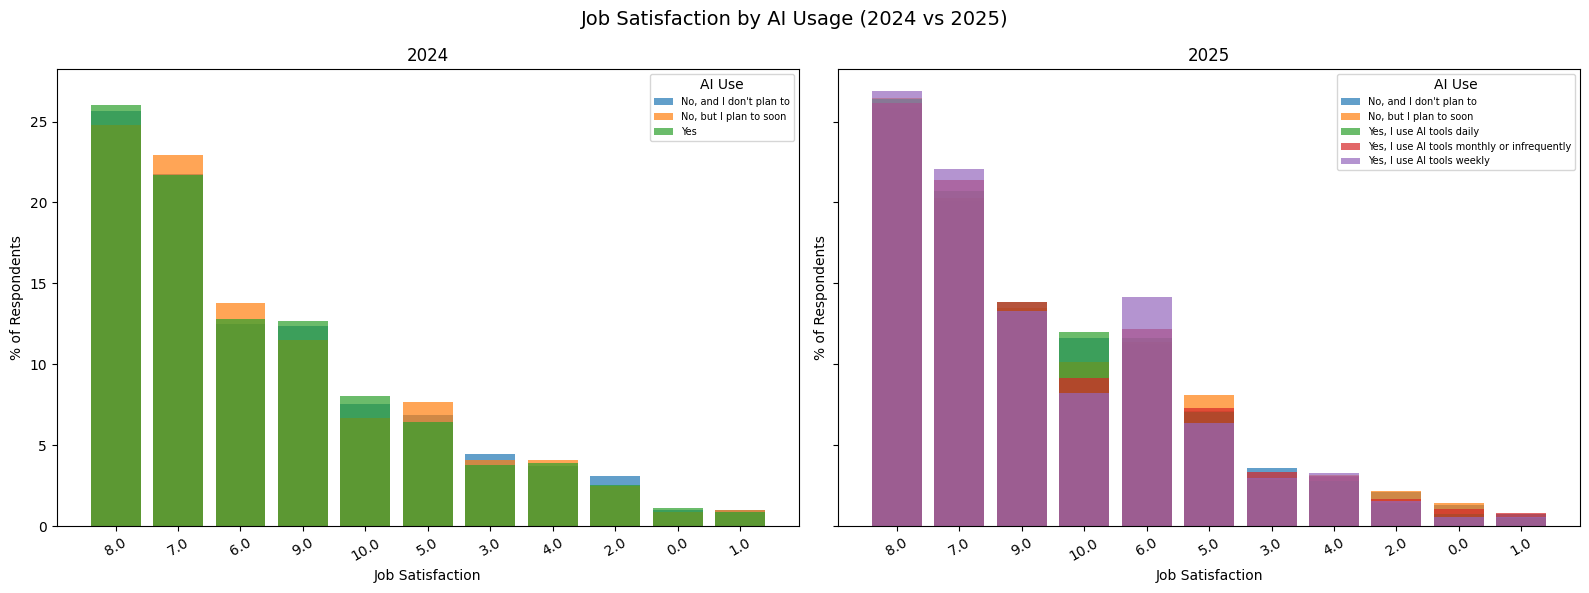

In [5]:
ai_sat = df[
    df['survey_year'].isin([2024, 2025])
    & df['ai_use'].notna()
    & df['job_sat'].notna()
].copy()

sat_by_ai = (
    ai_sat.groupby(['survey_year', 'ai_use'])['job_sat']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index(name='pct')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Job Satisfaction by AI Usage (2024 vs 2025)', fontsize=14)

for ax, year in zip(axes, [2024, 2025]):
    subset = sat_by_ai[sat_by_ai['survey_year'] == year]
    for ai_group, grp in subset.groupby('ai_use'):
        ax.bar(grp['job_sat'], grp['pct'], label=ai_group, alpha=0.7)
    ax.set_title(str(year))
    ax.set_xlabel('Job Satisfaction')
    ax.set_ylabel('% of Respondents')
    ax.legend(title='AI Use', fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [7]:
cols_to_drop = [
    # Never or barely available across years
    'ethnicity',
    'student',
    'undergrad_major',
    'age_first_code',
    'age_first_code_clean',
    'job_seek',
    'work_week_hrs',
    'work_week_hrs_clean',
    'learn_code_online',
    'coding_activities',
    'misc_tech',
    'webframe',
    'op_sys_prof',
    'ai_use',
    'ai_sent',
    
    'learn_code',
    'work_exp',
    'age_mid',
    'response_id',
    'main_branch',
    'gender',
    'country'
]

df_clean = df.drop(columns=cols_to_drop)
print(f"Columns remaining: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

Columns remaining: 42
['row_id', 'survey_year', 'country_clean', 'region', 'age', 'employment', 'employment_addl', 'employment_primary', 'is_paid_worker', 'is_full_time_employed', 'is_part_time_employed', 'is_independent', 'is_professional', 'education', 'education_clean', 'org_size', 'org_size_clean', 'ic_or_pm', 'ic_or_pm_clean', 'dev_type', 'industry', 'industry_clean', 'remote', 'remote_group', 'language', 'database', 'platform', 'language_count', 'database_count', 'platform_count', 'years_code', 'years_code_clean', 'years_code_pro', 'years_code_pro_clean', 'work_exp_clean', 'experience_proxy_source', 'professional_experience_years', 'role_family', 'job_sat', 'comp', 'comp_usd_clean', 'comp_real_2025']


In [8]:
df_clean = df_clean[~df_clean['survey_year'].isin([2021, 2022, 2023])]
print(df_clean['survey_year'].unique())
print(f"Rows remaining: {len(df_clean):,}")

[2015 2016 2017 2018 2019 2020 2024 2025]
Rows remaining: 500,335


In [9]:
for year in sorted(df_clean['survey_year'].unique()):
    unique_vals = df_clean[df_clean['survey_year'] == year]['job_sat'].dropna().unique()
    print(f"\n{year}:")
    for val in unique_vals:
        print(f"  {val}")


2015:
  I'm somewhat satisfied with my job
  I'm neither satisfied nor dissatisfied with my job
  I love my job
  I'm somewhat dissatisfied with my job
  I hate my job
  Other (please specify)

2016:
  I love my job
  I don't have a job
  I'm somewhat satisfied with my job
  I'm somewhat dissatisfied with my job
  I'm neither satisfied nor dissatisfied
  Other (please specify)
  I hate my job

2017:
  9.0
  3.0
  8.0
  6.0
  7.0
  5.0
  4.0
  10.0
  2.0
  0.0
  1.0

2018:
  Extremely satisfied
  Moderately dissatisfied
  Moderately satisfied
  Neither satisfied nor dissatisfied
  Slightly satisfied
  Slightly dissatisfied
  Extremely dissatisfied

2019:
  Slightly satisfied
  Slightly dissatisfied
  Neither satisfied nor dissatisfied
  Very satisfied
  Very dissatisfied

2020:
  Slightly satisfied
  Very dissatisfied
  Slightly dissatisfied
  Very satisfied
  Neither satisfied nor dissatisfied

2024:
  8.0
  5.0
  10.0
  6.0
  9.0
  4.0
  7.0
  3.0
  2.0
  1.0
  0.0

2025:
  10.0
  9.

In [10]:
# Map all years to a consistent 1-5 ordinal scale:
#   1 = Very Dissatisfied  2 = Dissatisfied  3 = Neutral  4 = Satisfied  5 = Very Satisfied
#
# 2015/2016: 5-point text  |  2018: 7-point text (collapsed to 5)
# 2019/2020: 5-point text  |  2017/2024/2025: 0-10 numeric (binned)

SAT_MAP = {
    # 2015 & 2016
    "I hate my job":                                         1,
    "I'm somewhat dissatisfied with my job":                2,
    "I'm neither satisfied nor dissatisfied with my job":   3,
    "I'm neither satisfied nor dissatisfied":               3,
    "I'm somewhat satisfied with my job":                   4,
    "I love my job":                                         5,
    "I don't have a job":                                   np.nan,
    "Other (please specify)":                                np.nan,

    # 2018 (7-point collapsed to 5)
    "Extremely dissatisfied":           1,
    "Moderately dissatisfied":          2,
    "Slightly dissatisfied":            2,
    "Neither satisfied nor dissatisfied": 3,
    "Slightly satisfied":               4,
    "Moderately satisfied":             4,
    "Extremely satisfied":              5,

    # 2019 & 2020
    "Very dissatisfied":    1,
    # "Slightly dissatisfied" already mapped above
    # "Neither satisfied nor dissatisfied" already mapped above
    # "Slightly satisfied" already mapped above
    "Very satisfied":       5,
}

def standardize_job_sat(row):
    val = row["job_sat"]
    year = row["survey_year"]

    if pd.isna(val):
        return np.nan

    # 2017, 2024, 2025: 0-10 numeric â€” bin to 1-5
    if year in [2017, 2024, 2025]:
        try:
            v = float(val)
        except:
            return np.nan
        if v <= 1:   return 1
        elif v <= 4: return 2
        elif v <= 6: return 3
        elif v <= 8: return 4
        else:        return 5

    return SAT_MAP.get(val, np.nan)

df_clean["job_sat_std"] = df_clean.apply(standardize_job_sat, axis=1)

# Sanity check
print(df_clean.groupby("survey_year")["job_sat_std"].agg(["mean", "median", "count"]))
print()
print(df_clean["job_sat_std"].value_counts().sort_index())


                 mean  median  count
survey_year                         
2015         3.999938     4.0  16004
2016         3.931820     4.0  39425
2017         3.751090     4.0  40376
2018         3.614210     4.0  69276
2019         3.685257     4.0  70988
2020         3.631411     4.0  45194
2024         3.734773     4.0  29126
2025         3.852606     4.0  26670

1.0     14057
2.0     46836
3.0     44968
4.0    140509
5.0     90689
Name: job_sat_std, dtype: int64


In [11]:
df_model = df_clean[df_clean['job_sat_std'].notna()].copy()

print(f"Rows before: {len(df_clean):,}")
print(f"Rows after:  {len(df_model):,}")
print(f"Dropped:     {len(df_clean) - len(df_model):,}")
print()
print(df_model.groupby('survey_year')['job_sat_std'].agg(['mean', 'median', 'count']))

Rows before: 500,335
Rows after:  337,059
Dropped:     163,276

                 mean  median  count
survey_year                         
2015         3.999938     4.0  16004
2016         3.931820     4.0  39425
2017         3.751090     4.0  40376
2018         3.614210     4.0  69276
2019         3.685257     4.0  70988
2020         3.631411     4.0  45194
2024         3.734773     4.0  29126
2025         3.852606     4.0  26670


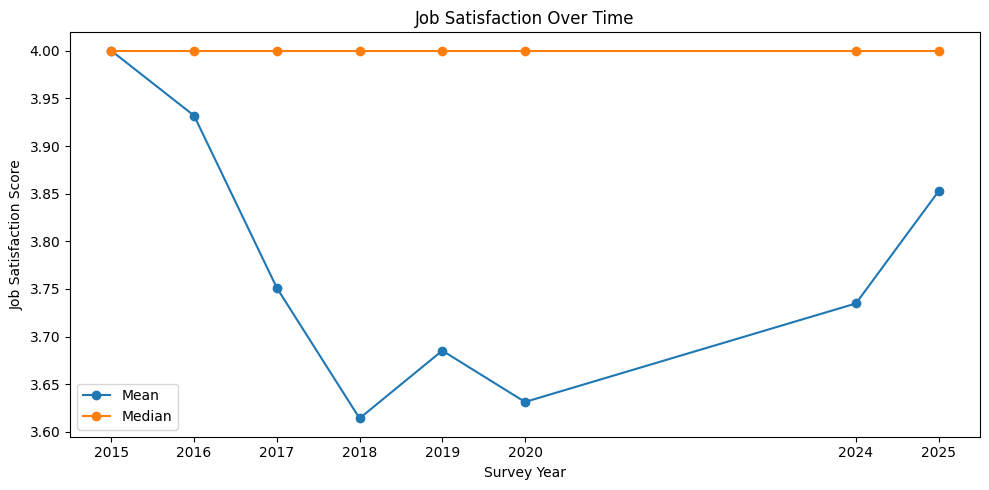

In [12]:
sat_by_year = (
    df_model.groupby('survey_year')['job_sat_std']
    .agg(['mean', 'median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sat_by_year['survey_year'], sat_by_year['mean'], marker='o', label='Mean')
ax.plot(sat_by_year['survey_year'], sat_by_year['median'], marker='o', label='Median')

ax.set_title('Job Satisfaction Over Time')
ax.set_xlabel('Survey Year')
ax.set_ylabel('Job Satisfaction Score')
ax.legend()
ax.set_xticks(sat_by_year['survey_year'])
plt.tight_layout()
plt.show()

In [13]:
print(df_model.groupby('survey_year').agg(
    total_rows=('job_sat', 'size'),
    non_null=('job_sat_std', lambda x: x.notna().sum()),
    null=('job_sat_std', lambda x: x.isna().sum()),
    pct_null=('job_sat_std', lambda x: round(x.isna().mean() * 100, 2)),
    mean_sat=('job_sat_std', 'mean'),
    median_sat=('job_sat_std', 'median'),
))

             total_rows  non_null  null  pct_null  mean_sat  median_sat
survey_year                                                            
2015              16004     16004     0       0.0  3.999938         4.0
2016              39425     39425     0       0.0  3.931820         4.0
2017              40376     40376     0       0.0  3.751090         4.0
2018              69276     69276     0       0.0  3.614210         4.0
2019              70988     70988     0       0.0  3.685257         4.0
2020              45194     45194     0       0.0  3.631411         4.0
2024              29126     29126     0       0.0  3.734773         4.0
2025              26670     26670     0       0.0  3.852606         4.0


In [15]:
df_clean['sat_missing'] = df_clean['job_sat_std'].isna().astype(int)
print(df_clean.groupby('survey_year')['sat_missing'].mean())
print(df_clean.groupby('region')['sat_missing'].mean())

survey_year
2015    0.386491
2016    0.296359
2017    0.214352
2018    0.299216
2019    0.201332
2020    0.298894
2024    0.554900
2025    0.457828
Name: sat_missing, dtype: float64
region
Africa      0.437049
Americas    0.255103
Asia        0.365735
Europe      0.284995
Oceania     0.268346
Name: sat_missing, dtype: float64


mostly full-time employed professionals, 

by removing all job_sat that are null, we can see that 97% of students and unemployed left job sat na. 
additionally almost half of people from africa left job_sat NA
modeling will underrepresent these groups 

In [16]:
null_by_year = (
    df_model.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

survey_year,2015,2016,2017,2018,2019,2020,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
survey_year,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country_clean,1.26,0.41,0.13,0.07,0.13,0.05,0.04,3.15
region,1.26,0.41,0.15,0.07,0.13,0.05,0.04,3.15
age,0.22,0.55,100.00,19.64,8.96,19.56,0.00,0.00
employment,0.22,0.11,0.00,0.00,0.47,0.28,0.00,0.00
employment_addl,100.00,100.00,100.00,100.00,100.00,100.00,100.00,5.78
employment_primary,0.22,0.11,0.00,0.00,0.08,0.28,0.00,0.00
is_paid_worker,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
is_full_time_employed,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [17]:
overall_null = df_model.isnull().mean().mul(100).round(2).reset_index()
overall_null.columns = ['column', 'overall_null_pct']
overall_null = overall_null.sort_values('overall_null_pct', ascending=False)

# flag columns over 50% null overall
majority_null = overall_null[overall_null['overall_null_pct'] > 50]
print("Columns with >50% nulls overall:")
print(majority_null.to_string(index=False))

Columns with >50% nulls overall:
         column  overall_null_pct
employment_addl             92.54
       ic_or_pm             84.71
 ic_or_pm_clean             84.71
 work_exp_clean             83.70
 industry_clean             67.71
       industry             56.91


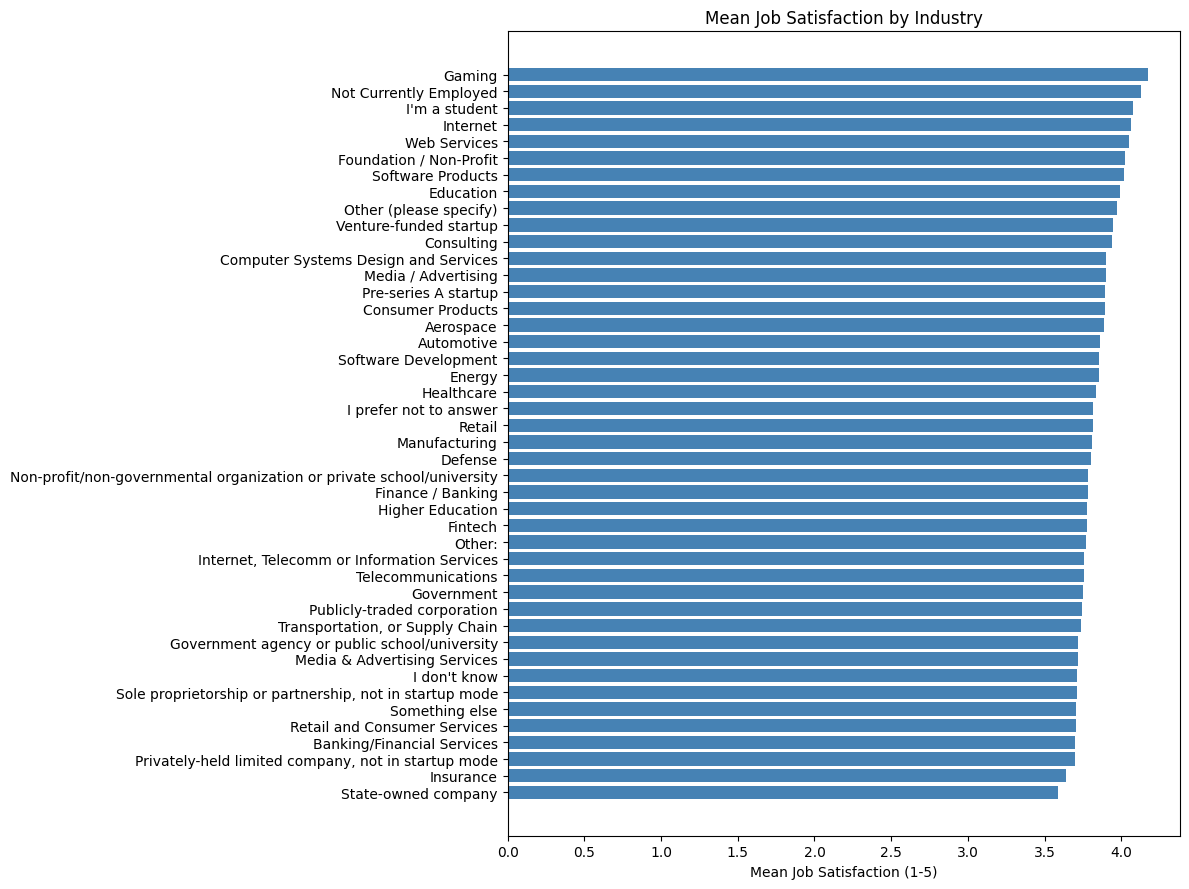

In [18]:
industry_sat = (
    df_model[df_model['industry'].notna()]
    .groupby('industry')['job_sat_std']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(industry_sat['industry'], industry_sat['job_sat_std'], color='steelblue')
ax.set_title('Mean Job Satisfaction by Industry')
ax.set_xlabel('Mean Job Satisfaction (1-5)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
cols_to_drop = [
    # Non-features
    "row_id",
    "country_clean",       # too granular; region already captures geography

    # Raw target variants (keep job_sat_std)
    "job_sat",
    "job_sat_num",         # 71.5% null

    # Redundant — raw versions superseded by cleaned columns
    "age",                 # 100% null in 2017; use age_group
    "employment",          # use employment_group
    "education",           # use education_clean
    "org_size",            # use org_size_clean
    "remote",              # use remote_group
    "years_code",          # use years_code_clean

    # Redundant compensation columns (keep log_comp_real_2025)
    "comp",
    "comp_usd_clean",
    "log_comp_usd_clean",
    "comp_real_2025",

    #'years_code_pro_clean

    # Raw multi-select strings (keep *_count columns)
    "language",
    "database",
    "platform",
]

df_model = df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns])
print(f"Columns remaining: {len(df_model.columns)}")
print(df_model.columns.tolist())


Columns remaining: 28
['survey_year', 'region', 'employment_addl', 'employment_primary', 'is_paid_worker', 'is_full_time_employed', 'is_part_time_employed', 'is_independent', 'is_professional', 'education_clean', 'org_size_clean', 'ic_or_pm', 'ic_or_pm_clean', 'dev_type', 'industry', 'industry_clean', 'remote_group', 'language_count', 'database_count', 'platform_count', 'years_code_clean', 'years_code_pro', 'years_code_pro_clean', 'work_exp_clean', 'experience_proxy_source', 'professional_experience_years', 'role_family', 'job_sat_std']


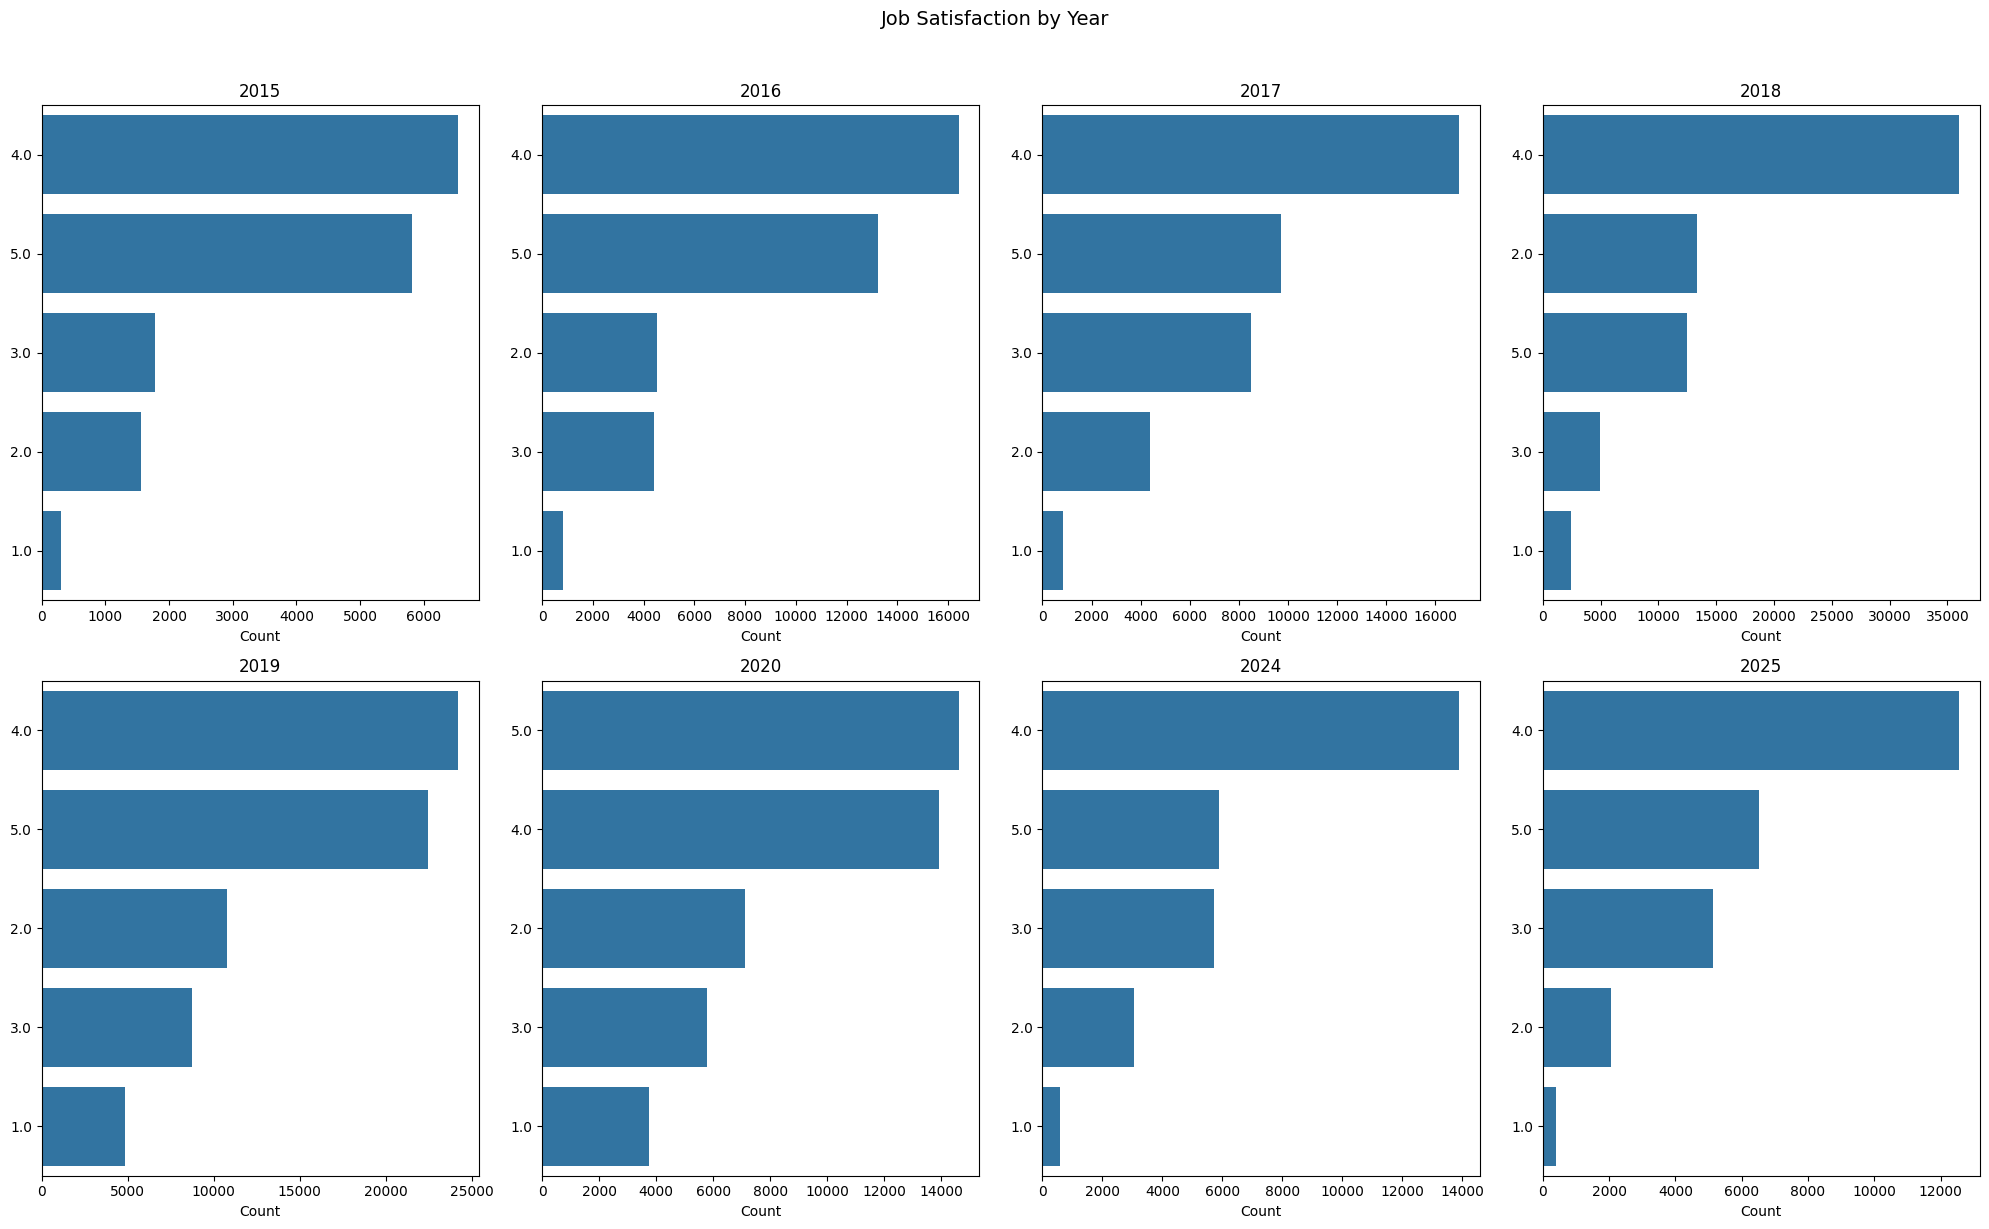

In [20]:
years = sorted(df_model['survey_year'].unique())
n = len(years)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(20, 12))
axes = axes.flatten()

for ax, year in zip(axes, years):
    df_year = df_model[df_model['survey_year'] == year]
    order = df_year['job_sat_std'].value_counts().index
    sns.countplot(data=df_year, y='job_sat_std', order=order, ax=ax)
    ax.set_title(str(year))
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Job Satisfaction by Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [21]:
EDU_MAP = {
    "Primary/elementary school":    "Below secondary",
    "Secondary school":             "Below secondary",
    "No formal education / other":  "Below secondary",
    "Other / ungrouped":            "Below secondary",
    "Some college/university":      "Some college",
    "Associate degree":             "Some college",
    "Bachelor's degree":            "Bachelor's",
    "Master's degree":              "Postgraduate",
    "Professional degree":          "Postgraduate",
    "Doctoral degree":              "Postgraduate",
}

df_model["education_clean"] = (
    df_model["education_clean"]
    .map(EDU_MAP)
    .fillna("Unknown")
)

print(df_model["education_clean"].value_counts())
print()
print(df_model.groupby("survey_year")["education_clean"].value_counts().unstack(fill_value=0))


Bachelor's         138838
Postgraduate        90191
Below secondary     57414
Some college        43928
Unknown              6688
Name: education_clean, dtype: int64

education_clean  Bachelor's  Below secondary  Postgraduate  Some college  \
survey_year                                                                
2015                   4956             6248          2172          1363   
2016                      0            32866          3322          1322   
2017                  18902             3046         11990          6086   
2018                  33459             4988         19467         10305   
2019                  34301             4254         20955         10225   
2020                  21988             2352         13593          6439   
2024                  13126             1942          9815          4243   
2025                  12106             1718          8877          3945   

education_clean  Unknown  
survey_year               
2015              

Continuous / count feature audit:


,feature,dtype,missing_pct,min,p01,p05,median,p95,p99,max,skew,iqr_lower_bound,iqr_upper_bound,pct_below_iqr_bound,pct_above_iqr_bound
4,work_exp_clean,float64,83.70,0.0,1.0,2.0,10.0,30.0,41.0,50.0,1.104,-14.5,37.5,0.0,0.34
2,database_count,float64,28.07,1.0,1.0,1.0,2.0,6.0,9.0,35.0,2.044,-3.5,8.5,0.0,0.77
3,platform_count,float64,25.10,1.0,1.0,1.0,2.0,6.0,9.0,27.0,1.624,-3.5,8.5,0.0,0.89
1,language_count,float64,7.64,1.0,1.0,1.0,4.0,10.0,13.0,47.0,1.576,-1.5,10.5,0.0,3.06
5,professional_experience_years,float64,7.08,0.0,0.5,1.0,6.0,23.0,34.0,50.0,1.623,-9.0,23.0,0.0,4.63
0,years_code_clean,float64,0.59,0.5,1.0,2.0,10.0,30.0,40.0,50.0,1.341,-9.0,31.0,0.0,3.69



Binary indicator feature audit:


,feature,dtype,missing_pct,mean,sum,value_counts
0,is_professional,bool,0.0,0.9335,314634,"{True: 314634, False: 22425}"


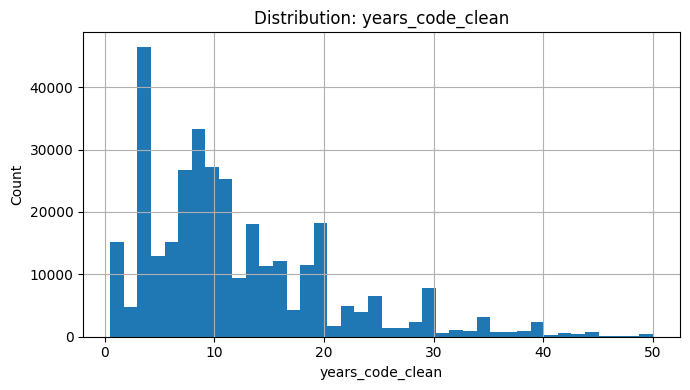

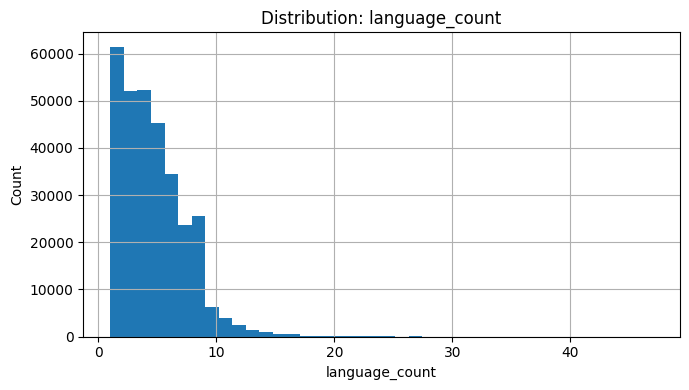

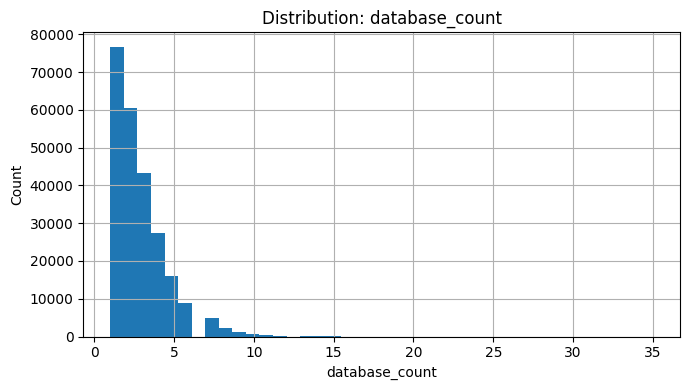

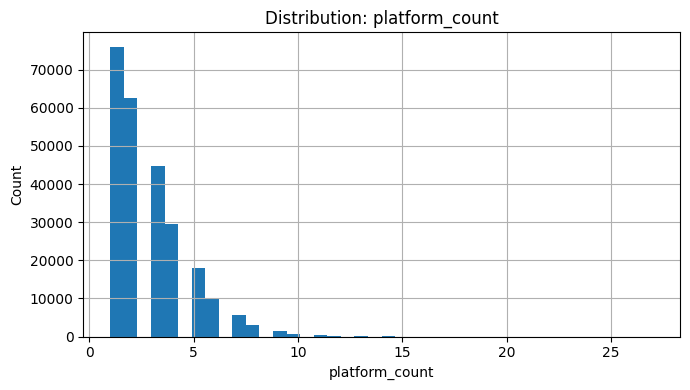

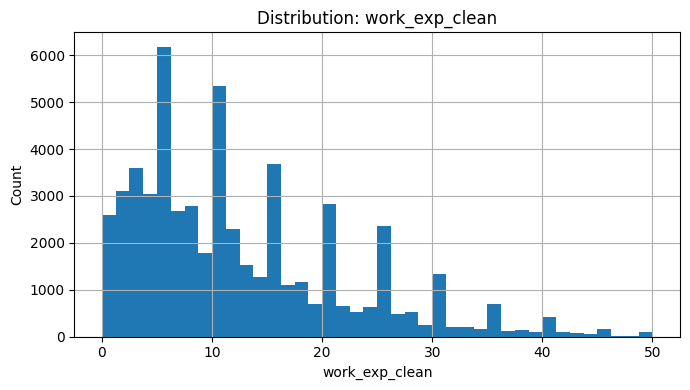

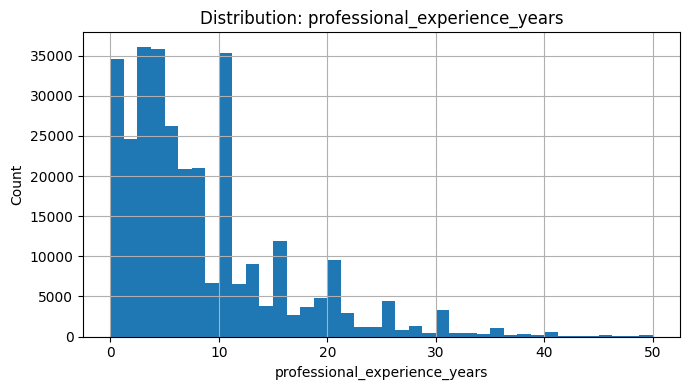

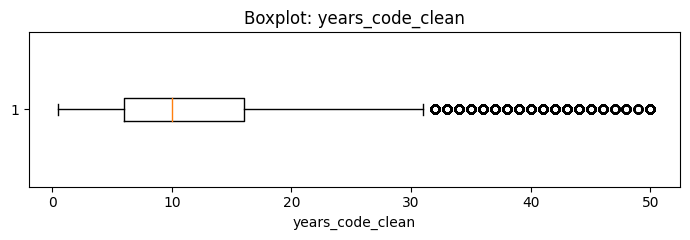

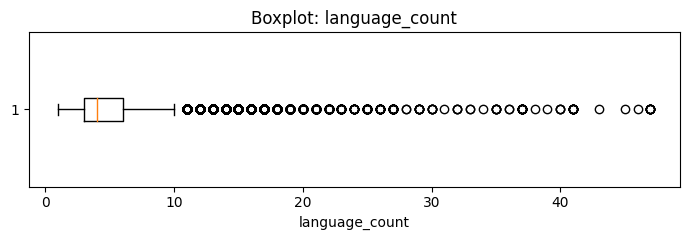

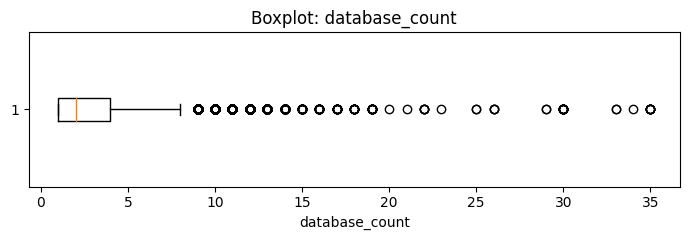

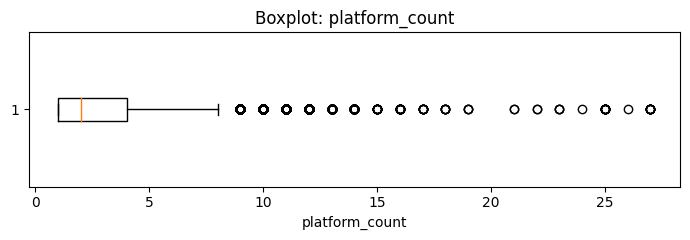

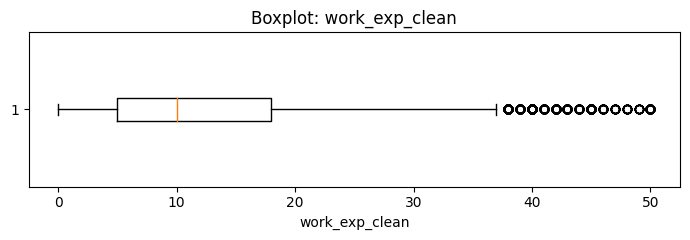

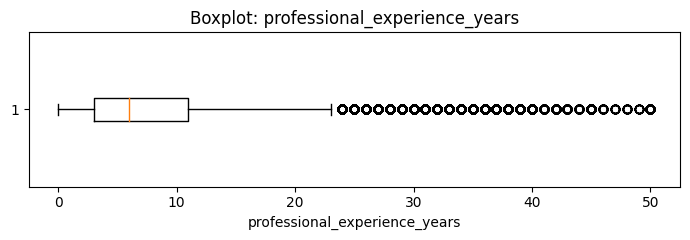

In [22]:
#checking numeric cols
cont_features = [
    'years_code_clean',
    'language_count',
    'database_count',
    'platform_count',
    'log_comp_real_2025',
    'work_exp_clean',
    'experience_proxy_years',
    'professional_experience_years',
    'role_family_count'
]
cont_features = [c for c in cont_features if c in df_model.columns]

binary_features = [
    'is_employed',
    'is_professional',
    'role_back_end',
    'role_data_ml',
    'role_desktop_enterprise',
    'role_devops_cloud',
    'role_front_end',
    'role_full_stack',
    'role_management',
    'role_mobile',
    'role_other',
    'role_qa_testing',
    'role_student_academic'
]
binary_features = [c for c in binary_features if c in df_model.columns]

audit_rows = []

for col in cont_features:
    s = pd.to_numeric(df_model[col], errors='coerce')

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr

    audit_rows.append({
        'feature': col,
        'dtype': str(df_model[col].dtype),
        'missing_pct': round(s.isna().mean() * 100, 2),
        'min': s.min(),
        'p01': s.quantile(0.01),
        'p05': s.quantile(0.05),
        'median': s.median(),
        'p95': s.quantile(0.95),
        'p99': s.quantile(0.99),
        'max': s.max(),
        'skew': round(s.skew(), 3),
        'iqr_lower_bound': lower_iqr,
        'iqr_upper_bound': upper_iqr,
        'pct_below_iqr_bound': round((s < lower_iqr).mean() * 100, 2),
        'pct_above_iqr_bound': round((s > upper_iqr).mean() * 100, 2),
    })

audit_df = pd.DataFrame(audit_rows).sort_values(['missing_pct', 'skew'], ascending=[False, False])

print("Continuous / count feature audit:")
display(audit_df)

binary_rows = []

for col in binary_features:
    s = df_model[col]
    if s.dtype == bool:
        s_num = s.astype(int)
    else:
        s_num = pd.to_numeric(s, errors='coerce')

    binary_rows.append({
        'feature': col,
        'dtype': str(df_model[col].dtype),
        'missing_pct': round(s_num.isna().mean() * 100, 2),
        'mean': round(s_num.mean(), 4),   
        'sum': s_num.sum(),
        'value_counts': s.value_counts(dropna=False).to_dict()
    })

binary_df = pd.DataFrame(binary_rows).sort_values('mean', ascending=False)

print("\nBinary indicator feature audit:")
display(binary_df)

for col in cont_features:
    plt.figure(figsize=(7, 4))
    pd.to_numeric(df_model[col], errors='coerce').dropna().hist(bins=40)
    plt.title(f'Distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

for col in cont_features:
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(pd.to_numeric(df_model[col], errors='coerce').dropna(), vert=False)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Clip summary:


,feature,lower_clip,upper_clip,before_min,before_max,after_min,after_max
0,years_code_clean,1.0,40.0,0.5,50.0,1.0,40.0
1,language_count,1.0,13.0,1.0,47.0,1.0,13.0
2,database_count,1.0,9.0,1.0,35.0,1.0,9.0
3,platform_count,1.0,9.0,1.0,27.0,1.0,9.0
4,work_exp_clean,1.0,41.0,0.0,50.0,1.0,41.0
5,professional_experience_years,0.5,34.0,0.0,50.0,0.5,34.0


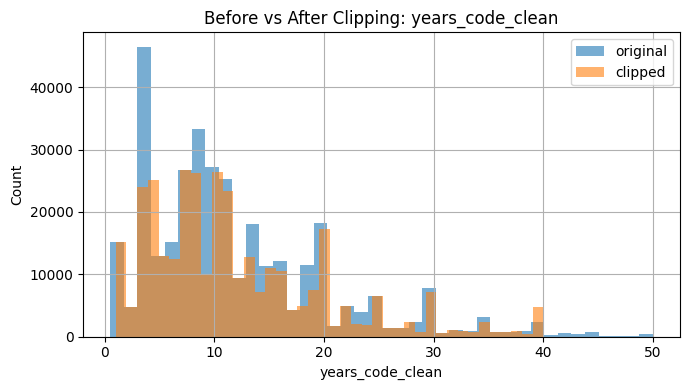

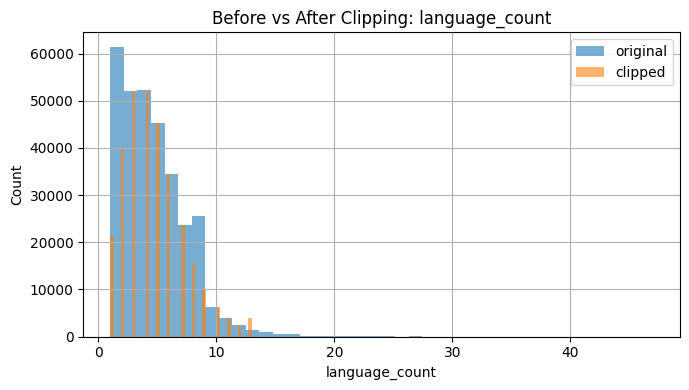

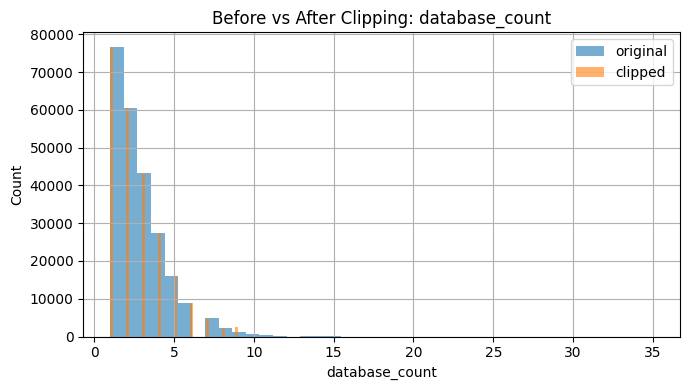

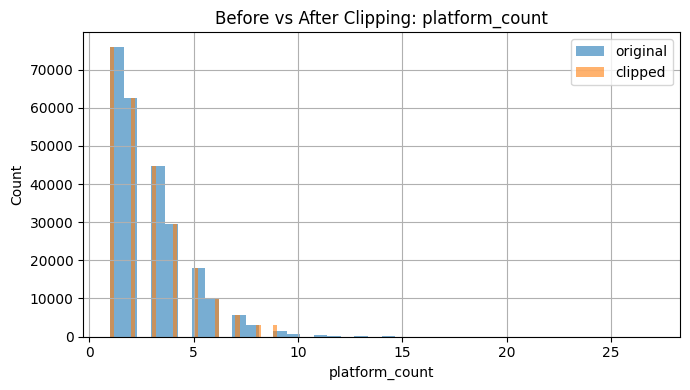

New binned columns added:
['years_code_bin', 'language_count_bin', 'database_count_bin', 'platform_count_bin']


In [23]:
#clipping outliers

df_model_improved = df_model.copy()
for col in cont_features:
    df_model_improved[col] = pd.to_numeric(df_model_improved[col], errors='coerce')
for col in binary_features:
    if col in df_model_improved.columns and df_model_improved[col].dtype == bool:
        df_model_improved[col] = df_model_improved[col].astype(int)
clip_summary = []

for col in cont_features:
    lower = df_model_improved[col].quantile(0.01)
    upper = df_model_improved[col].quantile(0.99)

    before_min = df_model_improved[col].min()
    before_max = df_model_improved[col].max()

    df_model_improved[col] = df_model_improved[col].clip(lower=lower, upper=upper)

    after_min = df_model_improved[col].min()
    after_max = df_model_improved[col].max()

    clip_summary.append({
        'feature': col,
        'lower_clip': lower,
        'upper_clip': upper,
        'before_min': before_min,
        'before_max': before_max,
        'after_min': after_min,
        'after_max': after_max
    })

clip_summary_df = pd.DataFrame(clip_summary)
print("Clip summary:")
display(clip_summary_df)

if 'years_code_clean' in df_model_improved.columns:
    df_model_improved['years_code_bin'] = pd.cut(
        df_model_improved['years_code_clean'],
        bins=[-np.inf, 2, 5, 10, 15, 20, np.inf],
        labels=['0-2', '3-5', '6-10', '11-15', '16-20', '21+']
    ).astype('category')

if 'log_comp_real_2025' in df_model_improved.columns:
    df_model_improved['comp_bin'] = pd.qcut(
        df_model_improved['log_comp_real_2025'],
        q=5,
        duplicates='drop'
    ).astype('category')

if 'language_count' in df_model_improved.columns:
    df_model_improved['language_count_bin'] = pd.cut(
        df_model_improved['language_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'database_count' in df_model_improved.columns:
    df_model_improved['database_count_bin'] = pd.cut(
        df_model_improved['database_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'platform_count' in df_model_improved.columns:
    df_model_improved['platform_count_bin'] = pd.cut(
        df_model_improved['platform_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'role_family_count' in df_model_improved.columns:
    df_model_improved['role_family_count_bin'] = pd.cut(
        df_model_improved['role_family_count'],
        bins=[-np.inf, 1, 2, 3, 4, np.inf],
        labels=['1', '2', '3', '4', '5+']
    ).astype('category')

#before vs after
for col in ['years_code_clean', 'log_comp_real_2025', 'language_count', 'database_count', 'platform_count', 'role_family_count']:
    if col not in df_model.columns or col not in df_model_improved.columns: continue
    fig, ax = plt.subplots(figsize=(7, 4))
    pd.to_numeric(df_model[col], errors='coerce').dropna().hist(bins=40, alpha=0.6, label='original', ax=ax)
    pd.to_numeric(df_model_improved[col], errors='coerce').dropna().hist(bins=40, alpha=0.6, label='clipped', ax=ax)
    ax.set_title(f'Before vs After Clipping: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()

print("New binned columns added:")
print([c for c in df_model_improved.columns if c.endswith('_bin')])

In [24]:
df_model_improved.columns

Index(['survey_year', 'region', 'employment_addl', 'employment_primary',
       'is_paid_worker', 'is_full_time_employed', 'is_part_time_employed',
       'is_independent', 'is_professional', 'education_clean',
       'org_size_clean', 'ic_or_pm', 'ic_or_pm_clean', 'dev_type', 'industry',
       'industry_clean', 'remote_group', 'language_count', 'database_count',
       'platform_count', 'years_code_clean', 'years_code_pro',
       'years_code_pro_clean', 'work_exp_clean', 'experience_proxy_source',
       'professional_experience_years', 'role_family', 'job_sat_std',
       'years_code_bin', 'language_count_bin', 'database_count_bin',
       'platform_count_bin'],
      dtype='object')

In [25]:
dupes = df_model_improved.columns[df_model_improved.columns.duplicated()]
print("Duplicate columns:", dupes.tolist())

Duplicate columns: []


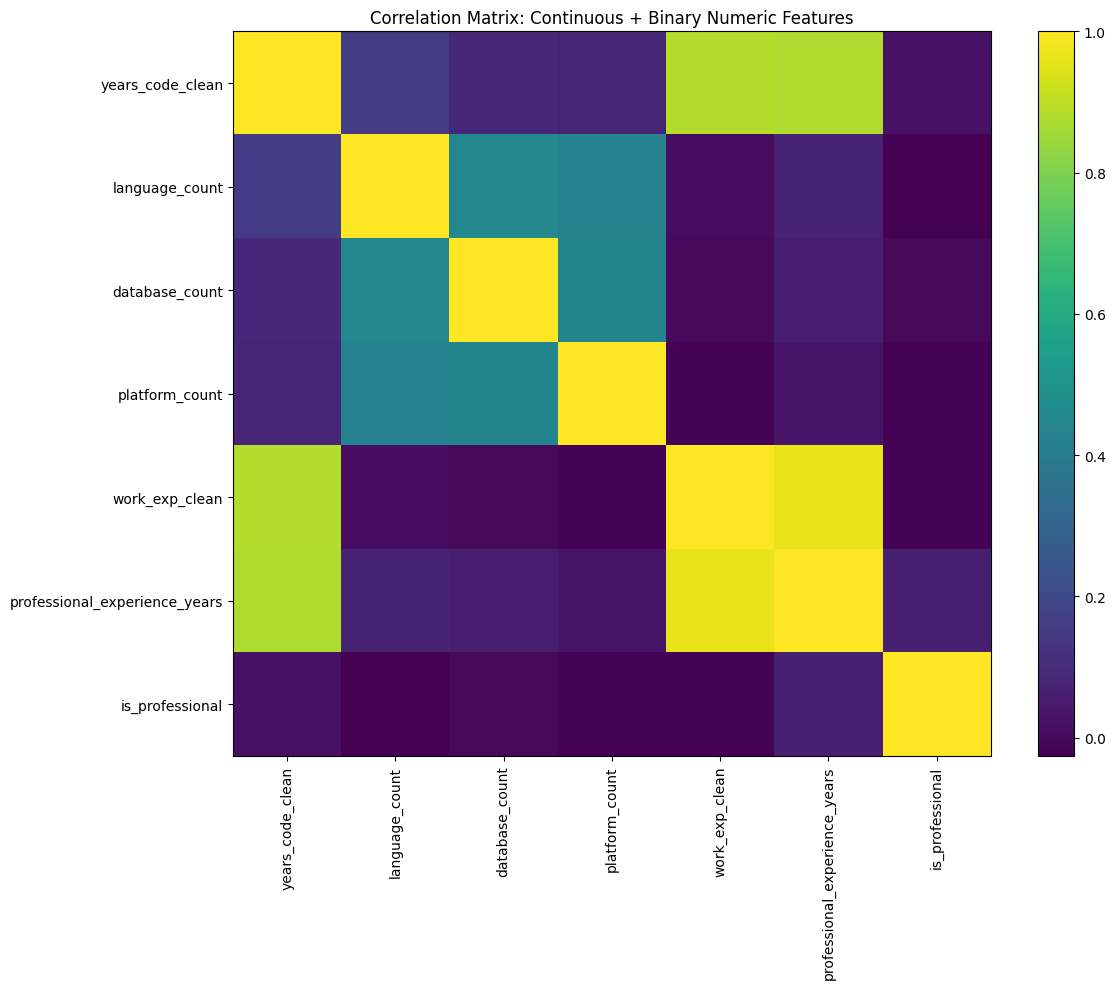

Strong correlation pairs (|corr| >= 0.70):


,feature_1,feature_2,corr
2,work_exp_clean,professional_experience_years,0.964
0,years_code_clean,work_exp_clean,0.880
1,years_code_clean,professional_experience_years,0.879


In [26]:
corr_cols = cont_features + binary_features
corr_cols = [c for c in corr_cols if c in df_model_improved.columns]
corr_df = df_model_improved[corr_cols].copy()

if corr_df.columns.duplicated().any():
    print("Dropping duplicate column names in corr_df:")
    print(corr_df.columns[corr_df.columns.duplicated()].tolist())
    corr_df = corr_df.loc[:, ~corr_df.columns.duplicated()].copy()

for col in corr_df.columns:
    series = corr_df[col]
    
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    
    if series.dtype == bool:
        corr_df[col] = series.astype(int)
    else:
        corr_df[col] = pd.to_numeric(series, errors='coerce')

corr = corr_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Matrix: Continuous + Binary Numeric Features')
plt.tight_layout()
plt.show()

strong_pairs = []
for i, col1 in enumerate(corr.columns):
    for j, col2 in enumerate(corr.columns):
        if j <= i:
            continue
        val = corr.loc[col1, col2]
        if pd.notna(val) and abs(val) >= 0.70:
            strong_pairs.append((col1, col2, round(val, 3)))

strong_pairs_df = pd.DataFrame(strong_pairs, columns=['feature_1', 'feature_2', 'corr'])

print("Strong correlation pairs (|corr| >= 0.70):")
if strong_pairs_df.empty:
    print("None found")
else:
    display(strong_pairs_df.sort_values('corr', ascending=False))

In [28]:
redundant_cols = ['work_exp_clean']

if redundant_cols:
    print("Dropping redundant columns:", redundant_cols)
    df_model_improved = df_model_improved.drop(columns=redundant_cols)
    cont_features = [c for c in cont_features if c in df_model_improved.columns]

Dropping redundant columns: ['work_exp_clean']


In [29]:
#Clustering:
df_model_improved.columns

Index(['survey_year', 'region', 'employment_addl', 'employment_primary',
       'is_paid_worker', 'is_full_time_employed', 'is_part_time_employed',
       'is_independent', 'is_professional', 'education_clean',
       'org_size_clean', 'ic_or_pm', 'ic_or_pm_clean', 'dev_type', 'industry',
       'industry_clean', 'remote_group', 'language_count', 'database_count',
       'platform_count', 'years_code_clean', 'years_code_pro',
       'years_code_pro_clean', 'experience_proxy_source',
       'professional_experience_years', 'role_family', 'job_sat_std',
       'years_code_bin', 'language_count_bin', 'database_count_bin',
       'platform_count_bin'],
      dtype='object')

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#For clustering, im only keeping what I think make most sense for behavioral segmentation 
c_features = [
    "region", 
    "employment_primary",
    "education_clean",
    "dev_type",
    "industry",
    "language_count",
    "years_code_clean",
    "professional_experience_years",
    "database_count",
    "platform_count",
    "org_size_clean",
    "remote_group"
]

df_cluster = df_model_improved[c_features].copy()
print(len(df_cluster))
df_cluster.dropna(inplace=True)
print(len(df_cluster))
df_cluster = df_cluster.sample(n=2500, replace=True, random_state=42, ignore_index=True)

df_cluster_2 = df_cluster.copy()

# df_cluster['is_student_status'] = df_cluster['is_student_status'].astype(str).map({'True': 1, 'False': 0, 'nan': np.nan, 'None': np.nan}).astype(float) 
# df_cluster['is_retired_status'] = df_cluster['is_retired_status'].astype(str).map({'True': 1, 'False': 0, 'nan': np.nan, 'None': np.nan}).astype(float)

for col in df_cluster.select_dtypes(exclude=np.number).columns: df_cluster[col] = df_cluster[col].astype(str).where(df_cluster[col].notna() & (df_cluster[col].astype(str) != 'nan'), other=np.nan)
categorical_cols = df_cluster.select_dtypes(exclude=np.number).columns.tolist()
numeric_cols = df_cluster.select_dtypes(include=np.number).columns.tolist()
print(f'Categorical Features: {categorical_cols} \nNumerical Features: {numeric_cols}')

# num_imputer = SimpleImputer(strategy='mean')
# cat_imputer = SimpleImputer(strategy='most_frequent')
# df_cluster[numeric_cols] = num_imputer.fit_transform(df_cluster[numeric_cols])
# df_cluster[categorical_cols] = cat_imputer.fit_transform(df_cluster[categorical_cols])

scaler = StandardScaler()
df_cluster[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster[categorical_cols] = df_cluster[categorical_cols].astype(str)

features = categorical_cols + numeric_cols
data = df_cluster[features]
data_matrix = data.to_numpy()
categorical_idx = [data.columns.get_loc(col) for col in categorical_cols]

337059
55088
Categorical Features: ['region', 'employment_primary', 'education_clean', 'dev_type', 'industry', 'org_size_clean', 'remote_group'] 
Numerical Features: ['language_count', 'years_code_clean', 'professional_experience_years', 'database_count', 'platform_count']


Cost for init method Huang: 10715.170716199325
Cost for init method Cao: 10704.491995876244
Cost for init method random: 10704.981747141901


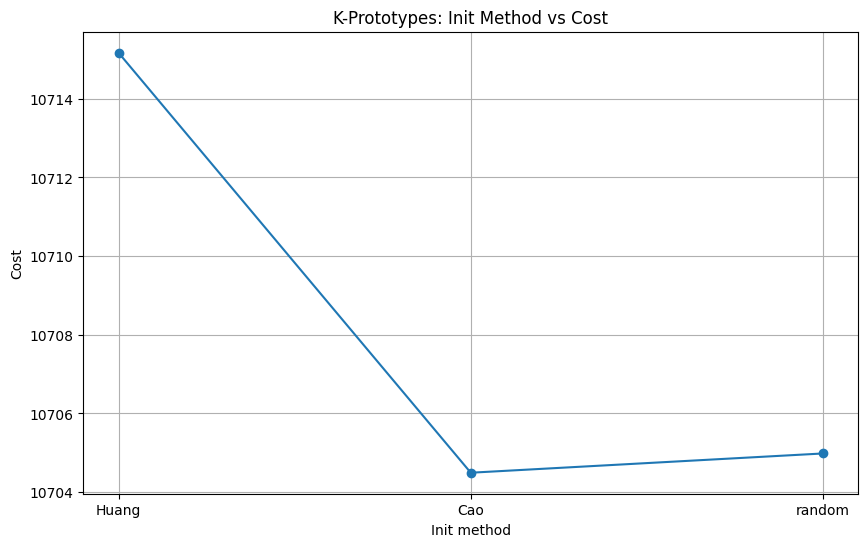

In [43]:
from kmodes.kprototypes import KPrototypes
def find_init_kproto(data, categorical_idx):
    init_tuning = ['Huang', 'Cao', 'random']
    cost = []

    for init in init_tuning:
        kproto = KPrototypes(n_clusters=4, init=init, random_state=32)
        clusters = kproto.fit_predict(data, categorical=categorical_idx)
        cost.append(kproto.cost_)
        print(f'Cost for init method {init}: {kproto.cost_}')

    plt.figure(figsize=(10, 6))
    plt.plot(init_tuning, cost, marker='o')
    plt.xlabel('Init method')
    plt.ylabel('Cost')
    plt.title('K-Prototypes: Init Method vs Cost')
    plt.grid(True)
    plt.show()
find_init_kproto(data_matrix, categorical_idx)

Cost for n_init = 4: 10705.848249126588
Cost for n_init = 8: 10704.491995876244
Cost for n_init = 12: 10704.491995876244
Cost for n_init = 16: 10704.491995876244
Cost for n_init = 20: 10704.491995876244


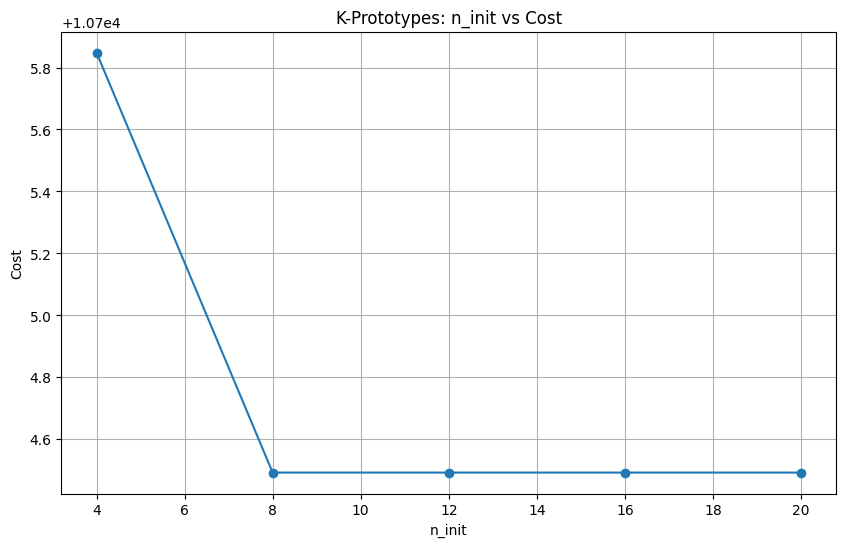

In [44]:
def find_ninit_kproto(data, categorical_idx):
    ninit_tuning = [4, 8, 12, 16, 20]
    cost = []

    for ninit in ninit_tuning:
        kproto = KPrototypes(n_clusters=4, init='Cao', n_init=ninit, random_state=32)
        clusters = kproto.fit_predict(data, categorical=categorical_idx)
        cost.append(kproto.cost_)
        print(f'Cost for n_init = {ninit}: {kproto.cost_}')

    plt.figure(figsize=(10, 6))
    plt.plot(ninit_tuning, cost, marker='o')
    plt.xlabel('n_init')
    plt.ylabel('Cost')
    plt.title('K-Prototypes: n_init vs Cost')
    plt.grid(True)
    plt.show()

find_ninit_kproto(data_matrix, categorical_idx)

Cost for max_iter = 100: 10704.491995876244
Cost for max_iter = 200: 10704.491995876244
Cost for max_iter = 300: 10704.491995876244


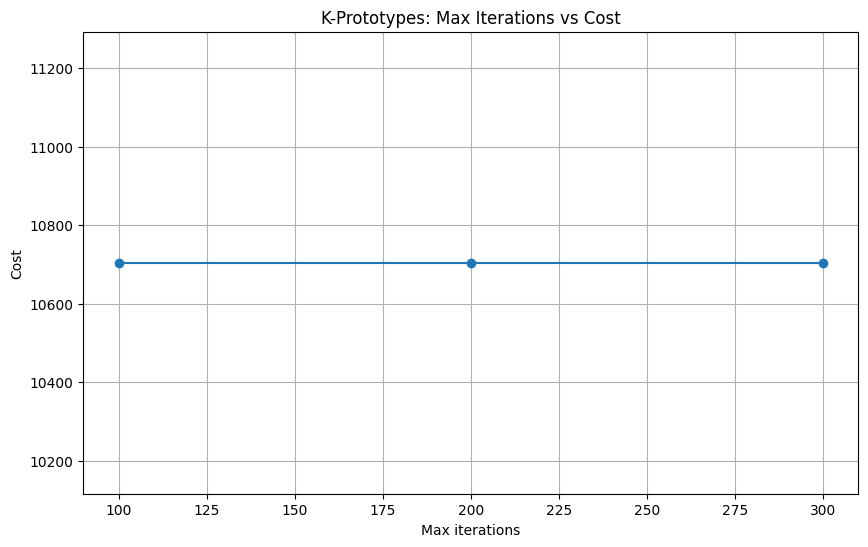

In [46]:
def find_max_kproto(data, categorical_idx):
    max_tuning = [100, 200, 300]
    cost = []

    for max_iter in max_tuning:
        kproto = KPrototypes(n_clusters=4, init='Cao', n_init=8, max_iter=max_iter, random_state=32)
        clusters = kproto.fit_predict(data, categorical=categorical_idx)
        cost.append(kproto.cost_)
        print(f'Cost for max_iter = {max_iter}: {kproto.cost_}')

    plt.figure(figsize=(10, 6))
    plt.plot(max_tuning, cost, marker='o')
    plt.xlabel('Max iterations')
    plt.ylabel('Cost')
    plt.title('K-Prototypes: Max Iterations vs Cost')
    plt.grid(True)
    plt.show()
find_max_kproto(data_matrix, categorical_idx)

Fit 1 clusters
Fit 2 clusters
Fit 3 clusters
Fit 4 clusters
Fit 5 clusters
Fit 6 clusters
Fit 7 clusters
Fit 8 clusters
Fit 9 clusters
Fit 10 clusters
Fit 11 clusters
Fit 12 clusters
Fit 13 clusters
Fit 14 clusters


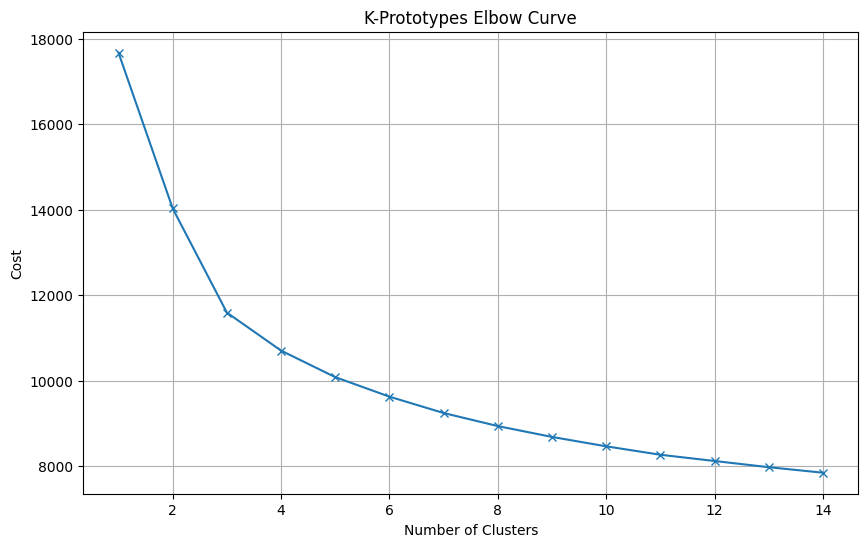

In [47]:
def find_num_clusters_kproto(data, categorical_idx, k):
    iters = range(1, k)
    cost = []

    for i in iters:
        kproto = KPrototypes(
            n_clusters=i,
            init='Cao',
            n_init=8,
            max_iter=100,
            random_state=32,
            verbose=0
        )
        clusters = kproto.fit_predict(data, categorical=categorical_idx)
        cost.append(kproto.cost_)
        print(f'Fit {i} clusters')

    plt.figure(figsize=(10, 6))
    plt.plot(list(iters), cost, 'x-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Cost')
    plt.title('K-Prototypes Elbow Curve')
    plt.grid(True)
    plt.show()

find_num_clusters_kproto(data_matrix, categorical_idx, 15)

In [50]:
cost = []
k = 3
kproto = KPrototypes(
    n_clusters=k,
    init='Cao',
    n_init=8,
    max_iter=100,
    random_state=32
)

clusters = kproto.fit_predict(data_matrix, categorical=categorical_idx)

cost.append(kproto.cost_)
print(cost)

df_cluster_2['Clusters'] = clusters

[11594.250559859689]


In [52]:
numeric_profile = df_cluster_2.groupby('Clusters')[numeric_cols].mean()
display(numeric_profile)

,language_count,years_code_clean,professional_experience_years,database_count,platform_count
Clusters,,,,,
0,0.054917,1.475242,1.542397,-0.057164,-0.208100
1,1.161292,-0.139575,-0.219484,1.274212,1.148608
2,-0.426937,-0.463104,-0.458350,-0.427688,-0.331176


In [54]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(pd.crosstab(df_cluster_2['Clusters'], df_cluster_2[col], normalize='index'))


=== region ===
region      Africa  Americas      Asia    Europe   Oceania
Clusters                                                  
0         0.005871  0.405088  0.056751  0.487280  0.045010
1         0.046422  0.286267  0.197292  0.437137  0.032882
2         0.019022  0.290761  0.188179  0.474864  0.027174

=== employment_primary ===
employment_primary  Employed full-time  Employed part-time  \
Clusters                                                     
0                             0.876712            0.050881   
1                             0.793037            0.106383   
2                             0.879755            0.052989   

employment_primary  Independent / contract  Not employed     Other   Retired  \
Clusters                                                                       
0                                 0.066536      0.001957  0.000000  0.001957   
1                                 0.085106      0.003868  0.000000  0.000000   
2                             

In [55]:
print(kproto.cluster_centroids_)

[['0.05491743147437398' '1.475242401074243' '1.5423969217066682'
  '-0.057164370862522976' '-0.2080995160495952' 'Europe'
  'Employed full-time' "Bachelor's" 'Developer, full-stack'
  'Software Development' '20-99' 'Mostly remote']
 ['1.1612924339370847' '-0.1395753525612861' '-0.2194844431144187'
  '1.274211986394326' '1.1486077372331862' 'Europe' 'Employed full-time'
  "Bachelor's" 'Developer, full-stack' 'Software Development' '100-999'
  'Mostly remote']
 ['-0.4269368178185512' '-0.463103539181219' '-0.45835011542252424'
  '-0.4276879099559232' '-0.33117618712514446' 'Europe'
  'Employed full-time' "Bachelor's" 'Developer, full-stack'
  'Software Development' '100-999' 'Mostly in-person']]


In [58]:
centroids = kproto.cluster_centroids_

n_num = len(numeric_cols)
n_cat = len(categorical_cols)

centroids_num = pd.DataFrame(
    centroids[:, :n_num].astype(float),
    columns=numeric_cols,
    index=[f'Cluster_{i+1}' for i in range(k)]
)

centroids_cat = pd.DataFrame(
    centroids[:, n_num:],
    columns=categorical_cols,
    index=[f'Cluster_{i+1}' for i in range(k)]
)

print("Numeric centroids:")
display(centroids_num)

print("\nCategorical centroids:")
display(centroids_cat)

Numeric centroids:


,language_count,years_code_clean,professional_experience_years,database_count,platform_count
Cluster_1,0.054917,1.475242,1.542397,-0.057164,-0.208100
Cluster_2,1.161292,-0.139575,-0.219484,1.274212,1.148608
Cluster_3,-0.426937,-0.463104,-0.458350,-0.427688,-0.331176



Categorical centroids:


,region,employment_primary,education_clean,dev_type,industry,org_size_clean,remote_group
Cluster_1,Europe,Employed full-time,Bachelor's,"Developer, full-stack",Software Development,20-99,Mostly remote
Cluster_2,Europe,Employed full-time,Bachelor's,"Developer, full-stack",Software Development,100-999,Mostly remote
Cluster_3,Europe,Employed full-time,Bachelor's,"Developer, full-stack",Software Development,100-999,Mostly in-person


In [59]:
for cluster_name, row in centroids_num.iterrows():
    print(f"\n{cluster_name}")

    strongest_positive = row.sort_values(ascending=False).head(5)
    strongest_negative = row.sort_values(ascending=True).head(5)

    print("Top positive numeric features:")
    print(strongest_positive)
    print("\nTop negative numeric features:")
    print(strongest_negative)
    print("\nCategorical profile:")
    print(centroids_cat.loc[cluster_name])


Cluster_1
Top positive numeric features:
professional_experience_years    1.542397
years_code_clean                 1.475242
language_count                   0.054917
database_count                  -0.057164
platform_count                  -0.208100
Name: Cluster_1, dtype: float64

Top negative numeric features:
platform_count                  -0.208100
database_count                  -0.057164
language_count                   0.054917
years_code_clean                 1.475242
professional_experience_years    1.542397
Name: Cluster_1, dtype: float64

Categorical profile:
region                               Europe
employment_primary       Employed full-time
education_clean                  Bachelor's
dev_type              Developer, full-stack
industry               Software Development
org_size_clean                        20-99
remote_group                  Mostly remote
Name: Cluster_1, dtype: object

Cluster_2
Top positive numeric features:
database_count                   1.2742